# **Chen Shmila, Alma Hova, Ohad Lavie**

# IEMOCAP Dataset  Exploratory Data Analysis


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


# <h1 style='color:purple;'>**Import Data**</h1>


In [4]:
from datasets import load_dataset

ds = load_dataset("AbstractTTS/IEMOCAP")

df = ds['train'].to_pandas()

README.md:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/489M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/456M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/462M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10039 [00:00<?, ? examples/s]

In [5]:
df.head()


,file,audio,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,...,EmoVal,EmoDom,gender,transcription,major_emotion,speaking_rate,pitch_mean,pitch_std,rms,relative_db
0,Ses01F_impro01_F000.wav,{'bytes': b'RIFFV\xf3\x00\x00WAVEfmt \x10\x00\...,0.006250,0.006250,0.00625,0.006250,0.00625,0.00625,0.950000,0.00625,...,2.666667,2.000000,Female,Excuse me.,neutral,5.14,202.798813,76.127853,0.007884,-17.938435
1,Ses01F_impro01_F001.wav,{'bytes': b'RIFF\xf2\xac\x00\x00WAVEfmt \x10\x...,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.761250,0.00625,...,2.333333,2.333333,Female,Yeah.,neutral,1.45,184.518967,18.823940,0.009273,-22.341549
2,Ses01F_impro01_F002.wav,{'bytes': b'RIFFl\x87\x01\x00WAVEfmt \x10\x00\...,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.572500,0.19500,...,2.666667,2.666667,Female,Is there a problem?,neutral,5.11,199.979996,23.654751,0.007846,-21.383230
3,Ses01F_impro01_F003.wav,{'bytes': b'RIFFT\xbb\x00\x00WAVEfmt \x10\x00\...,0.383750,0.383750,0.00625,0.006250,0.00625,0.00625,0.195000,0.00625,...,2.333333,3.000000,Female,You did.,neutral,4.01,175.226746,20.317553,0.013659,-18.791922
4,Ses01F_impro01_F004.wav,{'bytes': b'RIFF\xec\xaa\x01\x00WAVEfmt \x10\x...,0.320833,0.320833,0.00625,0.163542,0.00625,0.00625,0.163542,0.00625,...,2.666667,2.666667,Female,You were standing at the beginning and you di...,neutral,13.18,166.419769,58.883690,0.029505,-14.890097


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10039 entries, 0 to 10038
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   file           10039 non-null  str    
 1   audio          10039 non-null  object 
 2   frustrated     10039 non-null  float32
 3   angry          10039 non-null  float32
 4   sad            10039 non-null  float32
 5   disgust        10039 non-null  float32
 6   excited        10039 non-null  float32
 7   fear           10039 non-null  float32
 8   neutral        10039 non-null  float32
 9   surprise       10039 non-null  float32
 10  happy          10039 non-null  float32
 11  EmoAct         10039 non-null  float32
 12  EmoVal         10039 non-null  float32
 13  EmoDom         10039 non-null  float32
 14  gender         10039 non-null  str    
 15  transcription  10039 non-null  str    
 16  major_emotion  10039 non-null  str    
 17  speaking_rate  10039 non-null  float32
 18  pitch_mean     10

The dataset contains audio-file level annotations from the **IEMOCAP corpus** (Interactive Emotional Dyadic Motion Capture). Each row corresponds to a single audio record and includes emotions categories scores, dimensional emotion annotations (activation, valence, and dominance), acoustic features extracted from the speech signal, speaker metadata such as gender, and the audio transcription.


In [7]:
df.describe().round(3)


,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,EmoAct,EmoVal,EmoDom,speaking_rate,pitch_mean,pitch_std,rms,relative_db
count,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000
mean,0.236,0.142,0.118,0.012,0.135,0.017,0.209,0.028,0.103,3.096,2.787,3.208,9.397,179.478,45.311,0.020,-15.312
std,0.276,0.252,0.243,0.040,0.230,0.064,0.269,0.092,0.192,0.691,0.899,0.768,4.194,64.463,31.476,0.026,4.163
min,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,1.000,1.000,1.000,0.320,38.469,0.000,0.001,-34.411
25%,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,2.500,2.000,2.500,6.410,125.115,23.341,0.007,-17.887
50%,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,3.000,2.500,3.000,9.500,173.177,38.553,0.013,-15.119
75%,0.321,0.242,0.006,0.006,0.321,0.006,0.321,0.006,0.006,3.500,3.500,3.667,12.480,221.339,59.853,0.024,-12.463
max,0.950,0.950,0.950,0.635,0.950,0.950,0.950,0.950,0.950,5.000,5.000,5.000,38.710,618.340,301.505,0.482,-2.230


#### Columns Interpretation: 
**`file`:**	Audio filename / utterance ID <br>
**`audio`**	Audio waveform object<br>
**`frustrated → happy`:**	Emotion probability and soft label scores for each emotion<br>
**`EmoAct`:**	Emotional activation, values from 1 to 5<br>
**`EmoVal`:**	Emotional valence, values from 1 to 5<br>
**`EmoDom`:**	Emotional dominance, values from 1 to 5<br>
**`gender`:**	Speaker gender<br>
**`transcription`:**	Text transcription of the audio record<br>
**`major_emotion`:**	Main assigned emotion label<br>
**`speaking_rate`:**	Speed of speaking <br>
**`pitch_mean`:**	Mean fundamental frequency (voice pitch)<br>
**`pitch_std`:**	Variation in pitch<br>
**`rms`:** Root Mean Square energy — measures overall loudness and energy of the speech signal <br>
**`relative_db`:** Relative decibel level — loudness of the audio relative to a reference level <br>

In [8]:
df.shape


(10039, 22)

# <h1 style='color:purple;'>**Data Cleaning & EDA  Exploratory Data Analysis**</h1>


In [9]:
# Raw count of missing values per column
print(df.isnull().sum())


file             0
audio            0
frustrated       0
angry            0
sad              0
disgust          0
excited          0
fear             0
neutral          0
surprise         0
happy            0
EmoAct           0
EmoVal           0
EmoDom           0
gender           0
transcription    0
major_emotion    0
speaking_rate    0
pitch_mean       0
pitch_std        0
rms              0
relative_db      0
dtype: int64


<u>**Missing Value Strategy:**</u>  
The dataset contains **no missing values**, so no imputation is required.  


In [10]:
# Drop the columns that will now be used in the EDA 
df_eda = df.drop(columns=['audio', 'transcription'])

Check for duplicate rows

In [35]:
print(f"Duplicate rows: {df_eda.duplicated().sum()}")
print(f"Duplicate file names: {df_eda['file'].duplicated().sum()}")

Duplicate rows: 0
Duplicate file names: 0


In [11]:
df_eda.head()

,file,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,EmoAct,EmoVal,EmoDom,gender,major_emotion,speaking_rate,pitch_mean,pitch_std,rms,relative_db
0,Ses01F_impro01_F000.wav,0.006250,0.006250,0.00625,0.006250,0.00625,0.00625,0.950000,0.00625,0.00625,2.333333,2.666667,2.000000,Female,neutral,5.14,202.798813,76.127853,0.007884,-17.938435
1,Ses01F_impro01_F001.wav,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.761250,0.00625,0.00625,2.666667,2.333333,2.333333,Female,neutral,1.45,184.518967,18.823940,0.009273,-22.341549
2,Ses01F_impro01_F002.wav,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.572500,0.19500,0.00625,2.666667,2.666667,2.666667,Female,neutral,5.11,199.979996,23.654751,0.007846,-21.383230
3,Ses01F_impro01_F003.wav,0.383750,0.383750,0.00625,0.006250,0.00625,0.00625,0.195000,0.00625,0.00625,3.000000,2.333333,3.000000,Female,neutral,4.01,175.226746,20.317553,0.013659,-18.791922
4,Ses01F_impro01_F004.wav,0.320833,0.320833,0.00625,0.163542,0.00625,0.00625,0.163542,0.00625,0.00625,3.333333,2.666667,2.666667,Female,neutral,13.18,166.419769,58.883690,0.029505,-14.890097


Gender mapping: Female : 0 , Male : 1

In [12]:
df_eda['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [13]:
gender_mapping = {
    'Female': 0, 'Male': 1
}

df_eda['gender'] = df_eda['gender'].map(gender_mapping)

In [14]:
# Verify the changes
df_eda.head()

,file,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,EmoAct,EmoVal,EmoDom,gender,major_emotion,speaking_rate,pitch_mean,pitch_std,rms,relative_db
0,Ses01F_impro01_F000.wav,0.006250,0.006250,0.00625,0.006250,0.00625,0.00625,0.950000,0.00625,0.00625,2.333333,2.666667,2.000000,0,neutral,5.14,202.798813,76.127853,0.007884,-17.938435
1,Ses01F_impro01_F001.wav,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.761250,0.00625,0.00625,2.666667,2.333333,2.333333,0,neutral,1.45,184.518967,18.823940,0.009273,-22.341549
2,Ses01F_impro01_F002.wav,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.572500,0.19500,0.00625,2.666667,2.666667,2.666667,0,neutral,5.11,199.979996,23.654751,0.007846,-21.383230
3,Ses01F_impro01_F003.wav,0.383750,0.383750,0.00625,0.006250,0.00625,0.00625,0.195000,0.00625,0.00625,3.000000,2.333333,3.000000,0,neutral,4.01,175.226746,20.317553,0.013659,-18.791922
4,Ses01F_impro01_F004.wav,0.320833,0.320833,0.00625,0.163542,0.00625,0.00625,0.163542,0.00625,0.00625,3.333333,2.666667,2.666667,0,neutral,13.18,166.419769,58.883690,0.029505,-14.890097


In [15]:
df_eda['gender'].unique()

array([0, 1])

Check if emotion columns sum to 1 per row

In [16]:
emotion_cols = ['frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy']
row_sums = df_eda[emotion_cols].sum(axis=1)

print("Unique row sums:")
print(row_sums.unique())   # Show unique values

Unique row sums:
[1.         0.99999994 1.0000001  1.0000012  0.99999917 1.0000011
 0.9999991  1.000001   1.0000021  0.99999815 0.99999905 0.9999989
 1.000002  ]


<u>**Conclusions:**</u>  
As we have only a few unique values out of 10,000 records, we can infer that we are dealing with floating-point precision issue.<br>
In all of the records the emotionalt columns sum to 1, however due to numerical issues, we can see that it's not exactly 1. 

Verify major_emotion column consistency

In [17]:
df_eda['major_emotion'].unique()

<StringArray>
[   'neutral', 'frustrated',      'angry',        'sad',      'happy',
    'excited',   'surprise',       'fear',      'other',    'disgust']
Length: 10, dtype: str

Check for value consistency to ensure that all numeric values are in the same units

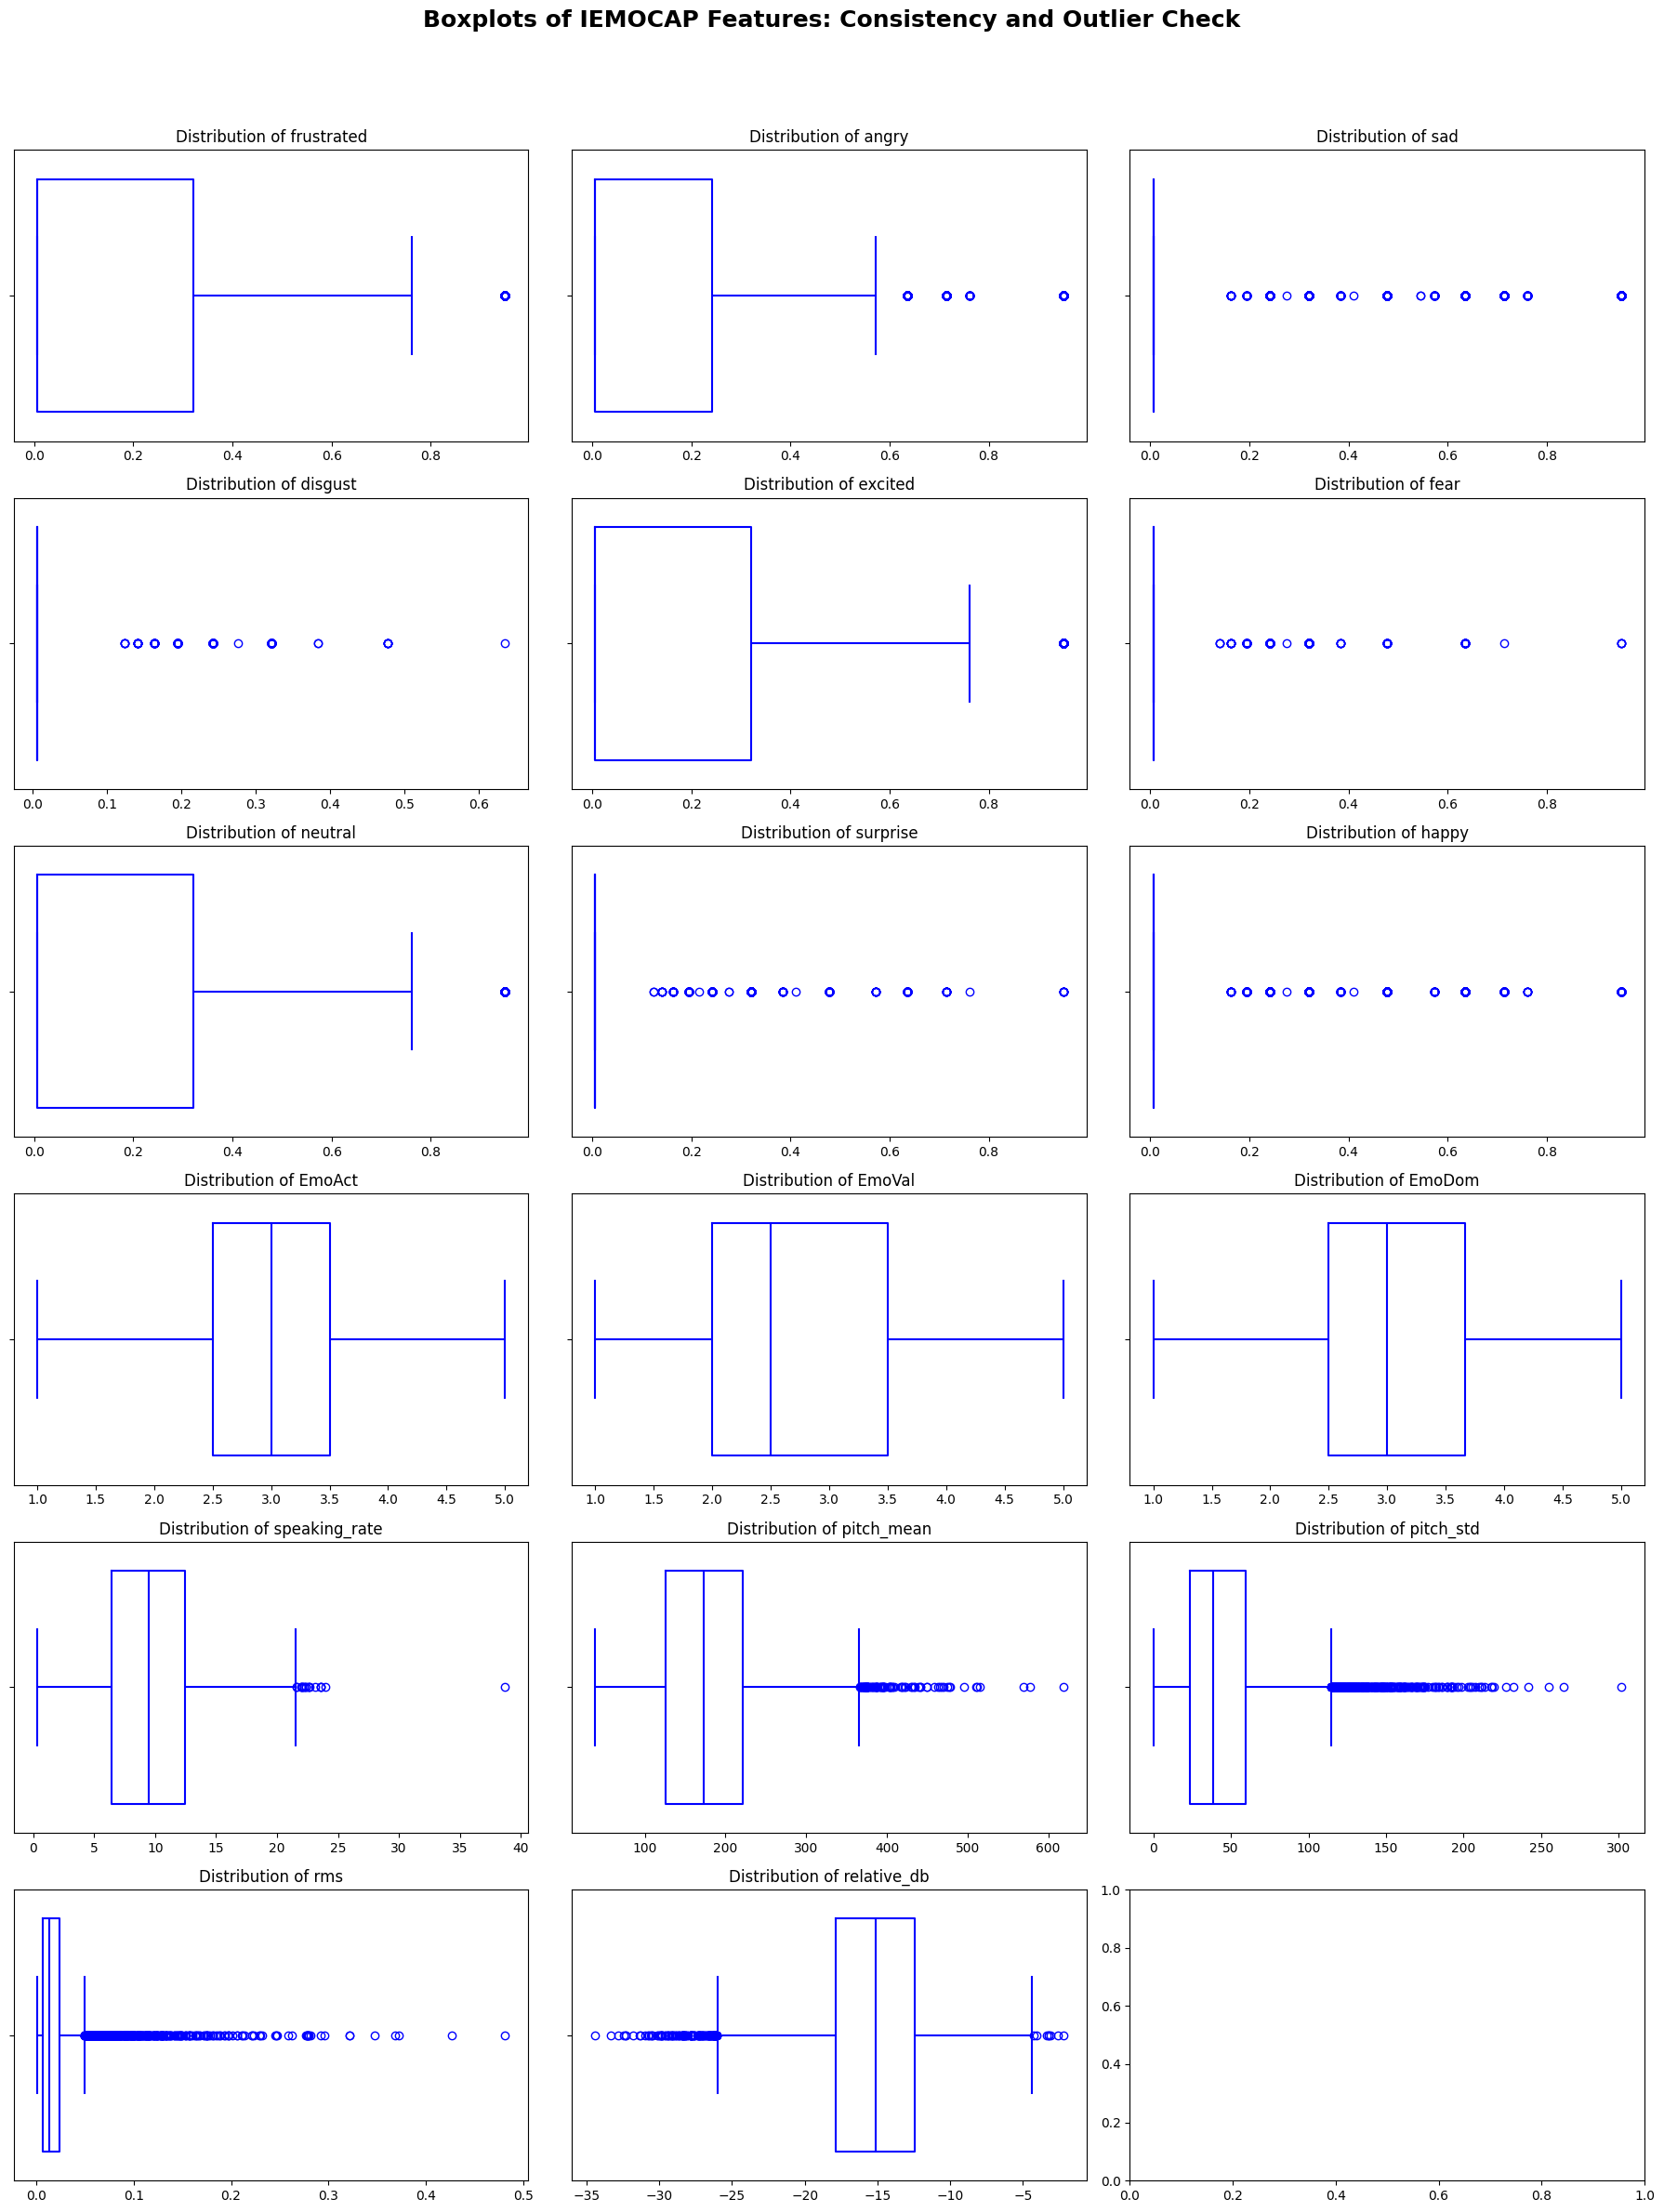

In [18]:
numerical_columns = ['frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 
    'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'speaking_rate', 
    'pitch_mean', 'pitch_std', 'rms', 'relative_db']

# Create a single figure with 17 subplots (6 row, 3 columns)
fig, axes = plt.subplots(6, 3, figsize=(18, 25))
axes_flat = axes.flatten()

# Loop through each column and plot in a subplot
for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df_eda, x=col, ax=axes_flat[i], fill=False, color='blue')
    axes_flat[i].set_title(f'Distribution of {col}', fontsize=12)
    axes_flat[i].set_xlabel('')

fig.suptitle('Boxplots of IEMOCAP Features: Consistency and Outlier Check', fontsize=18, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


<u>**Outliers Conclusions:**</u>  
As we can see by the Boxplot - there are some outlier. However not every outliers means a mistake. <bt>
After considering every plot and its actual meaning, we can say that the outliers are still in the valid values, as they representing genuine, rare emotional states rather than data errors.<br>
Therefore we would say that the data is consistent.

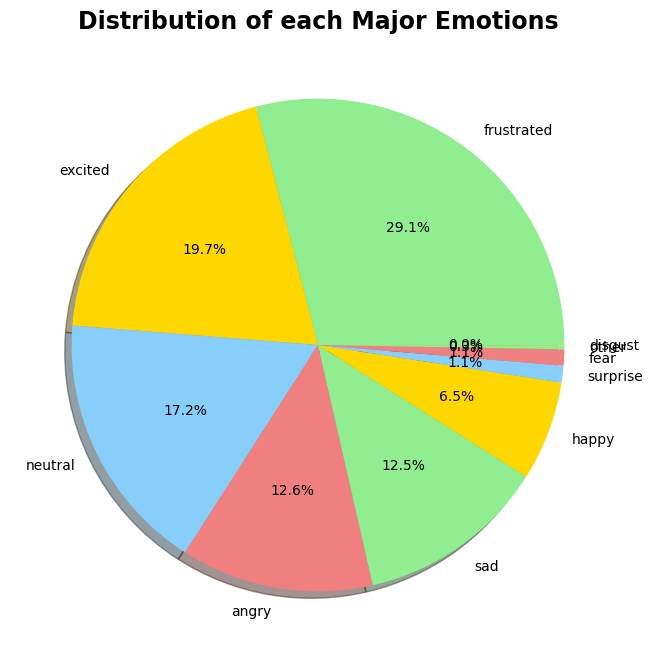

In [19]:
# Check the distribution of emotions across all observations
emotionsCount = df_eda['major_emotion'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(emotionsCount, labels=emotionsCount.index, shadow=True,autopct='%1.1f%%', colors=['lightgreen', 'gold', 'lightskyblue', 'lightcoral'] )

plt.title('Distribution of each Major Emotions', fontsize=17, weight='bold')
plt.show()

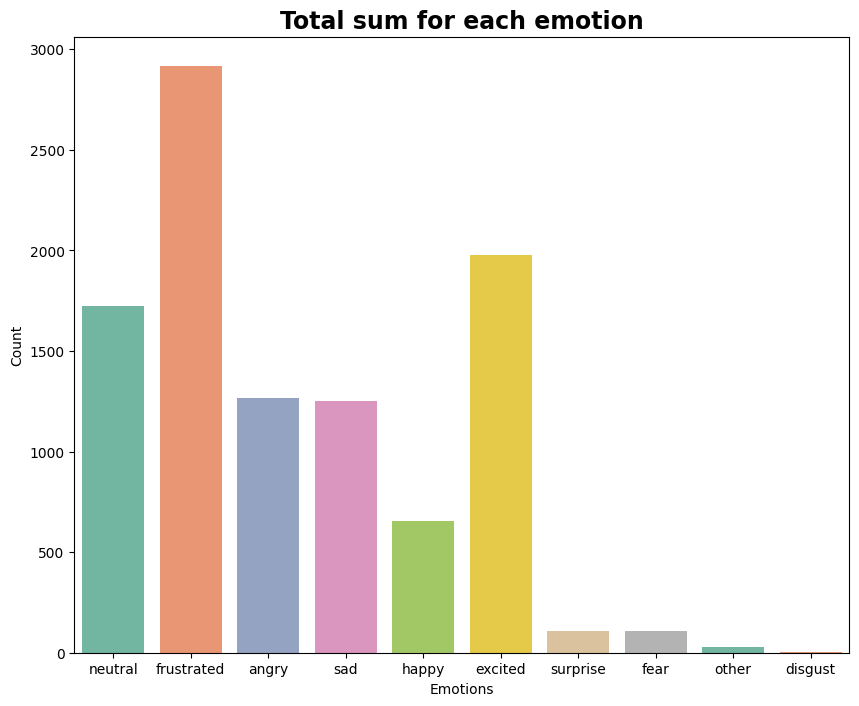

In [20]:
# Chart bar for major_emotion
plt.figure(figsize=(10, 8))
sns.countplot(df_eda, x='major_emotion', palette='Set2')

plt.title('Total sum for each emotion', fontsize=17 ,weight='bold')
plt.xlabel('Emotions')
plt.ylabel('Count')
plt.show()

Analyse emotion distribution using `major_emotion`, `gender`

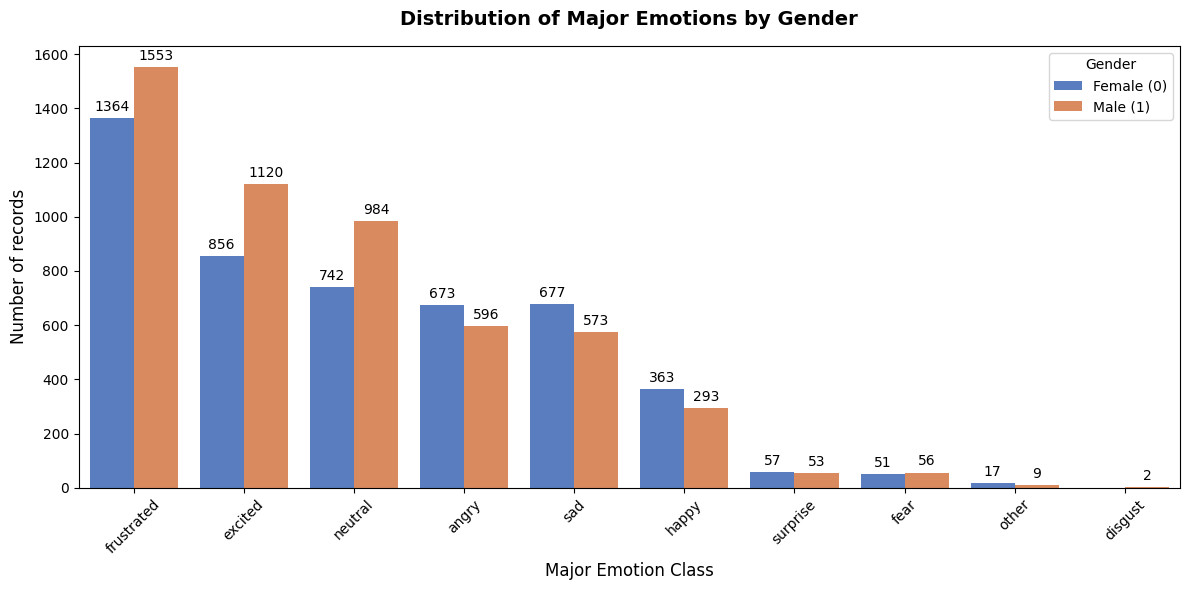

In [21]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_eda, 
    x='major_emotion', 
    hue='gender', 
    palette='muted',
    order=df_eda['major_emotion'].value_counts().index
)

# Add value labels on top of the bars for exact tracking
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Distribution of Major Emotions by Gender', fontsize=14, weight='bold', pad=15)
plt.xlabel('Major Emotion Class', fontsize=12)
plt.ylabel('Number of records', fontsize=12)
plt.legend(title='Gender', labels=['Female (0)', 'Male (1)'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Emotional Space Separation using `EmoVal`, `EmoAct`, `major_emotion`

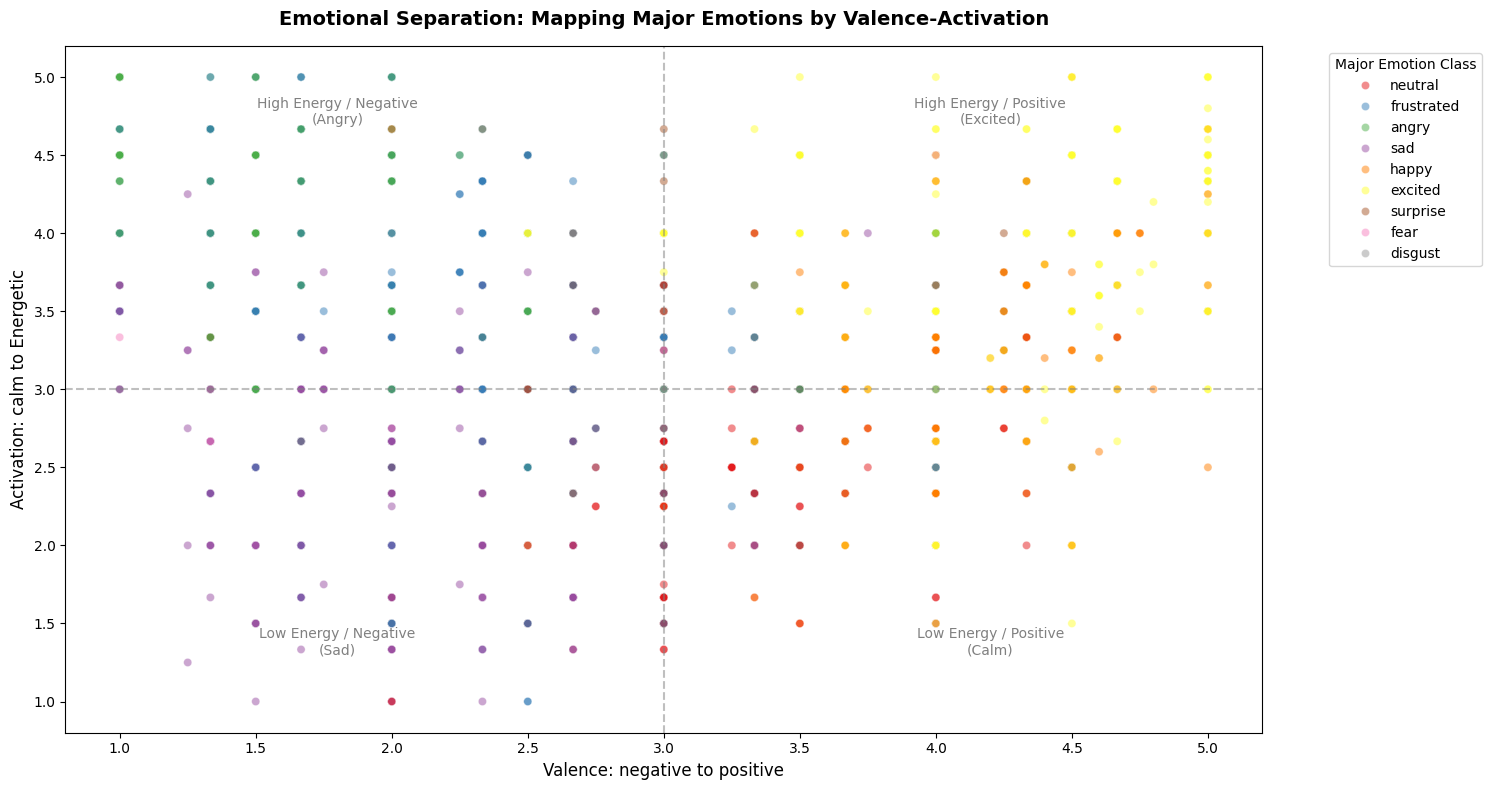

In [22]:
df_plot = df_eda[df_eda['major_emotion'].isin(emotion_cols)]

plt.figure(figsize=(15, 8))

# Create the scatter plot
sns.scatterplot(
    data=df_plot,
    x='EmoVal',          # Valence on X-axis, Negative to Positive
    y='EmoAct',          # Activation on Y-axis, Calm to Energetic
    hue='major_emotion',
    alpha=0.5,
    s=35,                # Size of the points
    palette='Set1'
)

plt.axvline(x=3.0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=3.0, color='gray', linestyle='--', alpha=0.5)

plt.text(4.2, 4.7, 'High Energy / Positive\n(Excited)', fontsize=10, color='gray', ha='center')
plt.text(1.8, 4.7, 'High Energy / Negative\n(Angry)', fontsize=10, color='gray', ha='center')
plt.text(1.8, 1.3, 'Low Energy / Negative\n(Sad)', fontsize=10, color='gray', ha='center')
plt.text(4.2, 1.3, 'Low Energy / Positive\n(Calm)', fontsize=10, color='gray', ha='center')

# Final presentation styling
plt.title('Emotional Separation: Mapping Major Emotions by Valence-Activation', fontsize=14, weight='bold', pad=15)
plt.xlabel('Valence: negative to positive', fontsize=12)
plt.ylabel('Activation: calm to Energetic', fontsize=12)
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.legend(title='Major Emotion Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Acoustic Profile to maps how different emotions physically sound

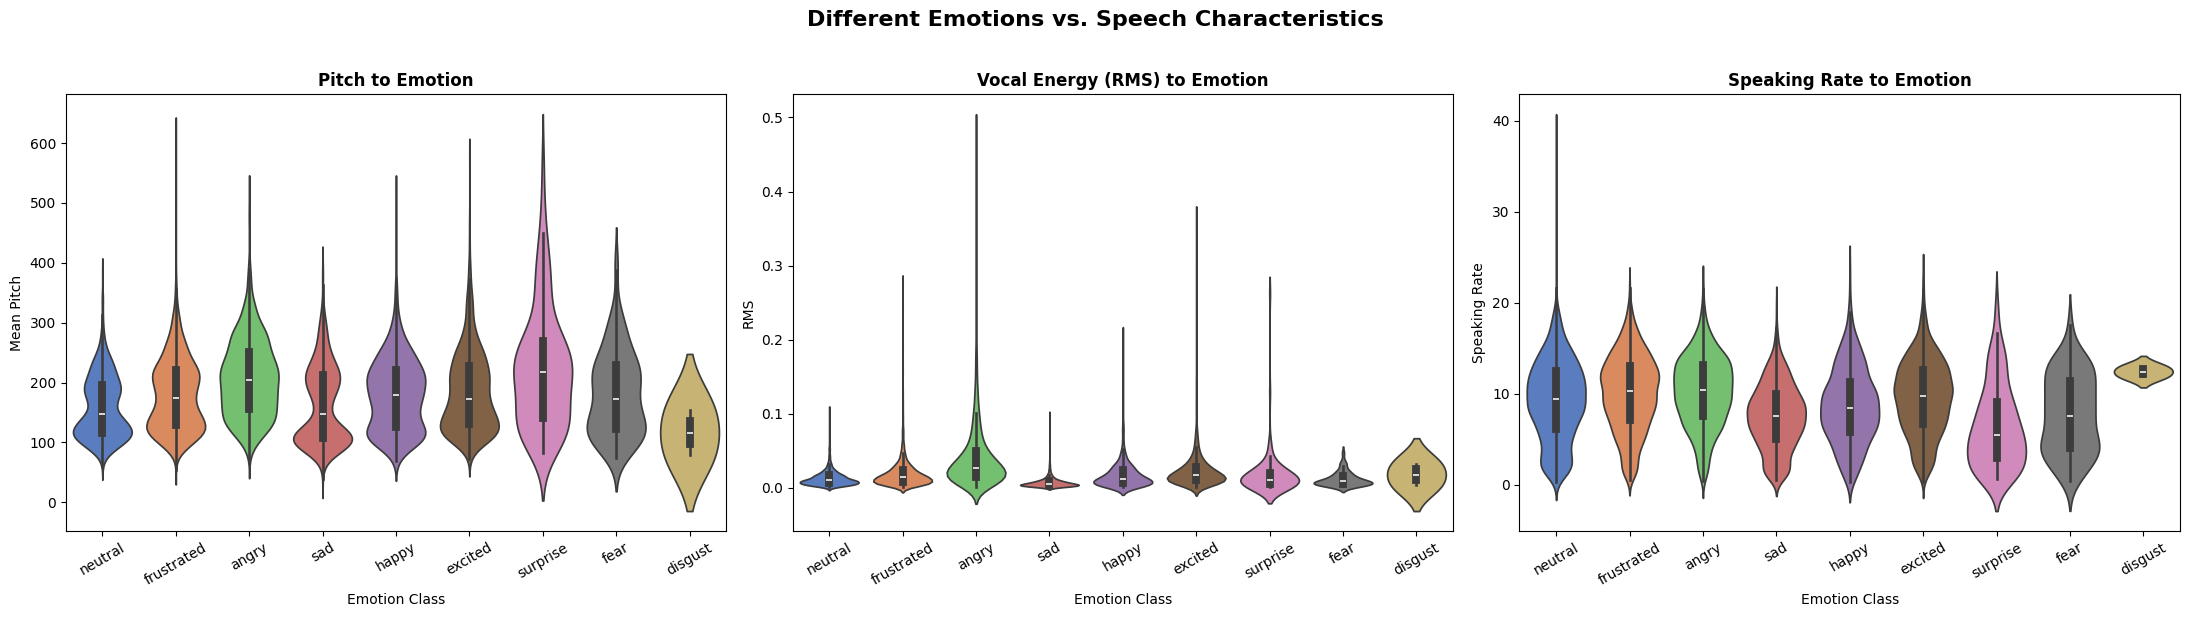

In [23]:
df_acoustic = df_eda[df_eda['major_emotion'].isin(emotion_cols)]

# Set up a 1-row, 3-column grid of plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Pitch Mean (Frequency/Tone)
sns.violinplot(data=df_acoustic, x='major_emotion', y='pitch_mean', ax=axes[0], palette='muted', hue='major_emotion', legend=False)
axes[0].set_title('Pitch to Emotion', fontsize=12, weight='bold')
axes[0].set_xlabel('Emotion Class')
axes[0].set_ylabel('Mean Pitch')
axes[0].tick_params(axis='x', rotation=30)

# Profile 2: RMS (Volume/Energy)
sns.violinplot(data=df_acoustic, x='major_emotion', y='rms', ax=axes[1], palette='muted', hue='major_emotion', legend=False)
axes[1].set_title('Vocal Energy (RMS) to Emotion', fontsize=12, weight='bold')
axes[1].set_xlabel('Emotion Class')
axes[1].set_ylabel('RMS')
axes[1].tick_params(axis='x', rotation=30)

# Profile 3: Speaking Rate (Tempo/Speed)
sns.violinplot(data=df_acoustic, x='major_emotion', y='speaking_rate', ax=axes[2], palette='muted', hue='major_emotion', legend=False)
axes[2].set_title('Speaking Rate to Emotion', fontsize=12, weight='bold')
axes[2].set_xlabel('Emotion Class')
axes[2].set_ylabel('Speaking Rate')
axes[2].tick_params(axis='x', rotation=30)

# 3. Final layout polishing
fig.suptitle('Different Emotions vs. Speech Characteristics', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Group by major_emotion and calculate the mean for each column
grouped_data = df_eda.groupby('major_emotion')[emotion_cols].mean()

grouped_data

,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy
major_emotion,,,,,,,,,
angry,0.183786,0.696858,0.021074,0.017798,0.012136,0.008389,0.033730,0.018802,0.007428
disgust,0.242188,0.006250,0.006250,0.556771,0.163541,0.006250,0.006250,0.006250,0.006250
excited,0.027774,0.012976,0.019185,0.008734,0.523864,0.010867,0.138746,0.032273,0.225581
fear,0.064610,0.044029,0.119000,0.012130,0.086366,0.457398,0.136346,0.053290,0.026830
frustrated,0.583207,0.144162,0.059478,0.016068,0.020472,0.012357,0.120900,0.021608,0.021747
happy,0.017447,0.007928,0.019557,0.007449,0.172078,0.006610,0.106188,0.023226,0.639517
neutral,0.130397,0.018890,0.035202,0.009194,0.055041,0.010433,0.699810,0.011198,0.029835
other,0.187740,0.163542,0.048598,0.024399,0.066747,0.018349,0.296635,0.078846,0.115144
sad,0.093539,0.032513,0.685766,0.009710,0.012680,0.024863,0.099575,0.012554,0.028799


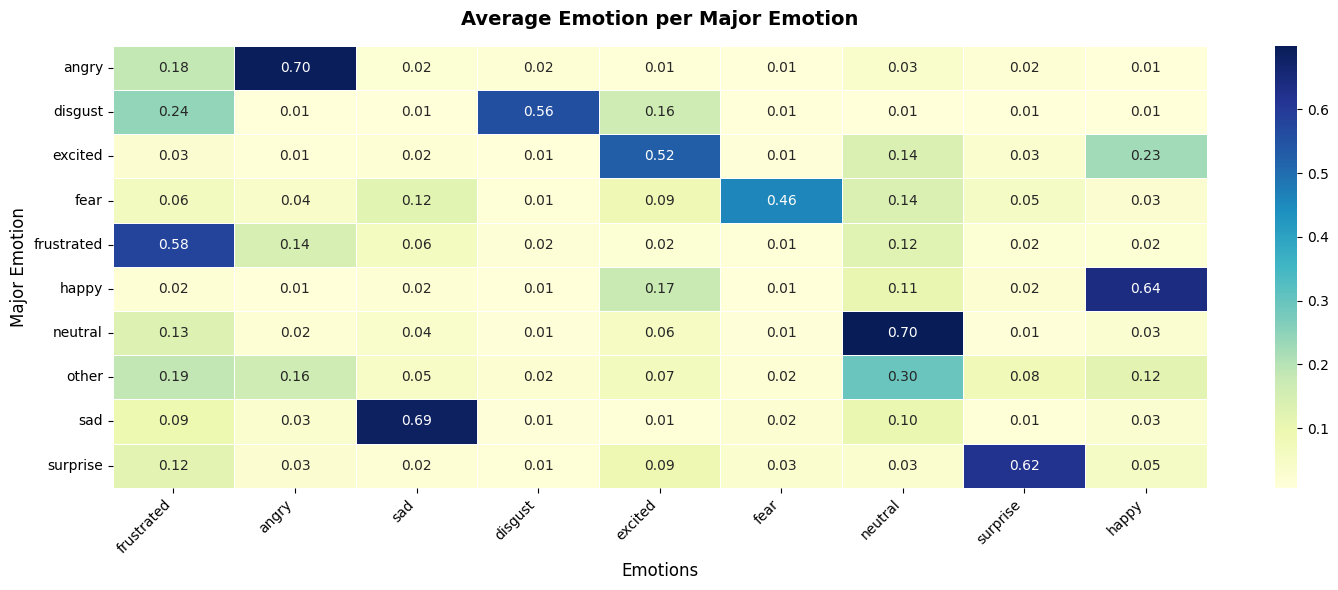

In [25]:
plt.figure(figsize=(15, 6))
sns.heatmap(
    grouped_data, 
    annot=True,          # Show the average values inside the cells
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap="YlGnBu",       # Yellow-to-blue color paYlette
    linewidths=0.5, 
)

plt.title('Average Emotion per Major Emotion', fontsize=14, weight='bold', pad=15)
plt.ylabel('Major Emotion', fontsize=12)
plt.xlabel('Emotions', fontsize=12)
plt.xticks(rotation=45, ha='right')  

plt.tight_layout()
plt.show()

Detailed class distribution including exact counts and proportions

In [26]:
emotion_counts = df_eda['major_emotion'].value_counts()
emotion_pct = (emotion_counts / len(df_eda) * 100).round(1)

class_summary = pd.DataFrame({
    'Count': emotion_counts,
    'Percentage (%)': emotion_pct
})

print("Emotion class distribution:\n")
print(class_summary.to_string())
print(f"\nTotal: {len(df_eda)} utterances")
print("\nNote: 'other' is a catch-all label for utterances with no clear majority emotion.")

Emotion class distribution:

               Count  Percentage (%)
major_emotion                       
frustrated      2917            29.1
excited         1976            19.7
neutral         1726            17.2
angry           1269            12.6
sad             1250            12.5
happy            656             6.5
surprise         110             1.1
fear             107             1.1
other             26             0.3
disgust            2             0.0

Total: 10039 utterances

Note: 'other' is a catch-all label for utterances with no clear majority emotion.


<u>**Conclusions:**</u>
The dataset is heavily imbalanced. `frustrated` (29.1%) and `excited` (19.7%) are the two most common classes, together making up nearly half the data, while `neutral` is third at 17.2%. At the other extreme, `disgust` has only 2 instances and `other` only 26 — both are too sparse to treat as independent classes in modeling. The strong class imbalance means simple accuracy is a misleading metric; weighted recall (UAR) or per-class F1 should be used instead.

Correlation between numerical features

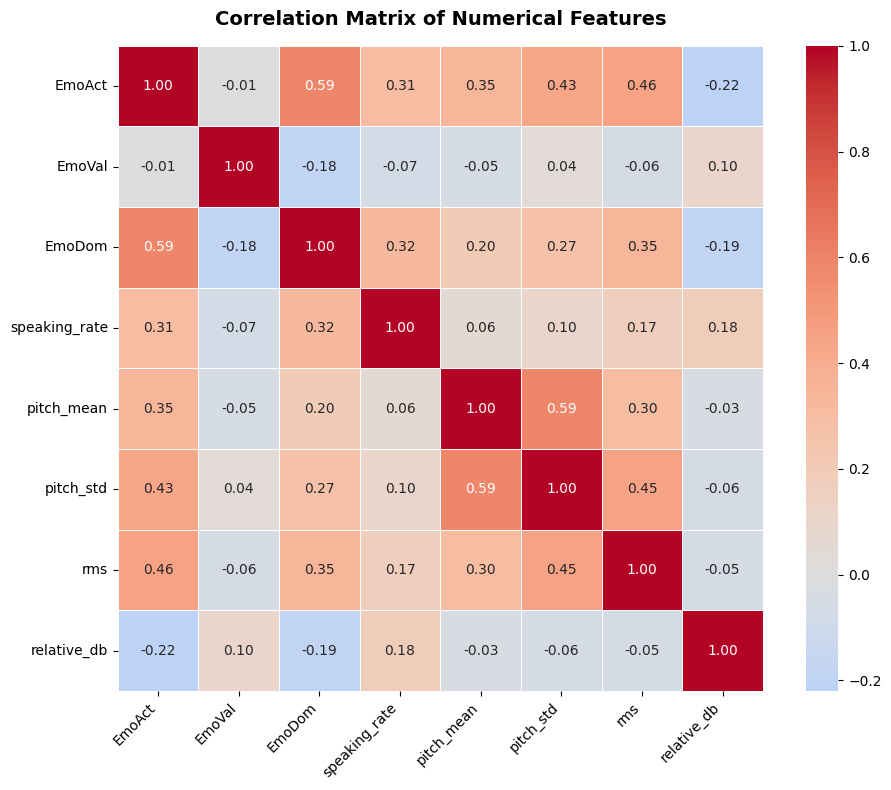

In [27]:
numerical_features = ['EmoAct', 'EmoVal', 'EmoDom',
                       'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']

corr_matrix = df_eda[numerical_features].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Matrix of Numerical Features', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<u>**Conclusions:**</u>
The strongest correlation in the matrix is between `EmoAct` and `EmoDom` (r = 0.59): high activation emotions also tend to feel dominant. `EmoAct` shows moderate positive correlations with several acoustic features: `rms` (0.46), `pitch_std` (0.43), `pitch_mean` (0.35), and `speaking_rate` (0.31), consistent with energetic emotions being louder, higher pitched, and faster paced. `pitch_mean` and `pitch_std` are also correlated (0.59), reflecting that speakers with higher average pitch also vary their pitch more. `EmoVal` is largely uncorrelated with all acoustic features, consistent with the known difficulty of predicting valence from acoustics alone. Notably, `rms` and `relative_db` show near zero correlation (r = −0.06), indicating they capture different aspects of loudness and should be treated as independent features rather than redundant ones.

Dimensional emotion profiles — Activation, Valence, and Dominance per emotion class

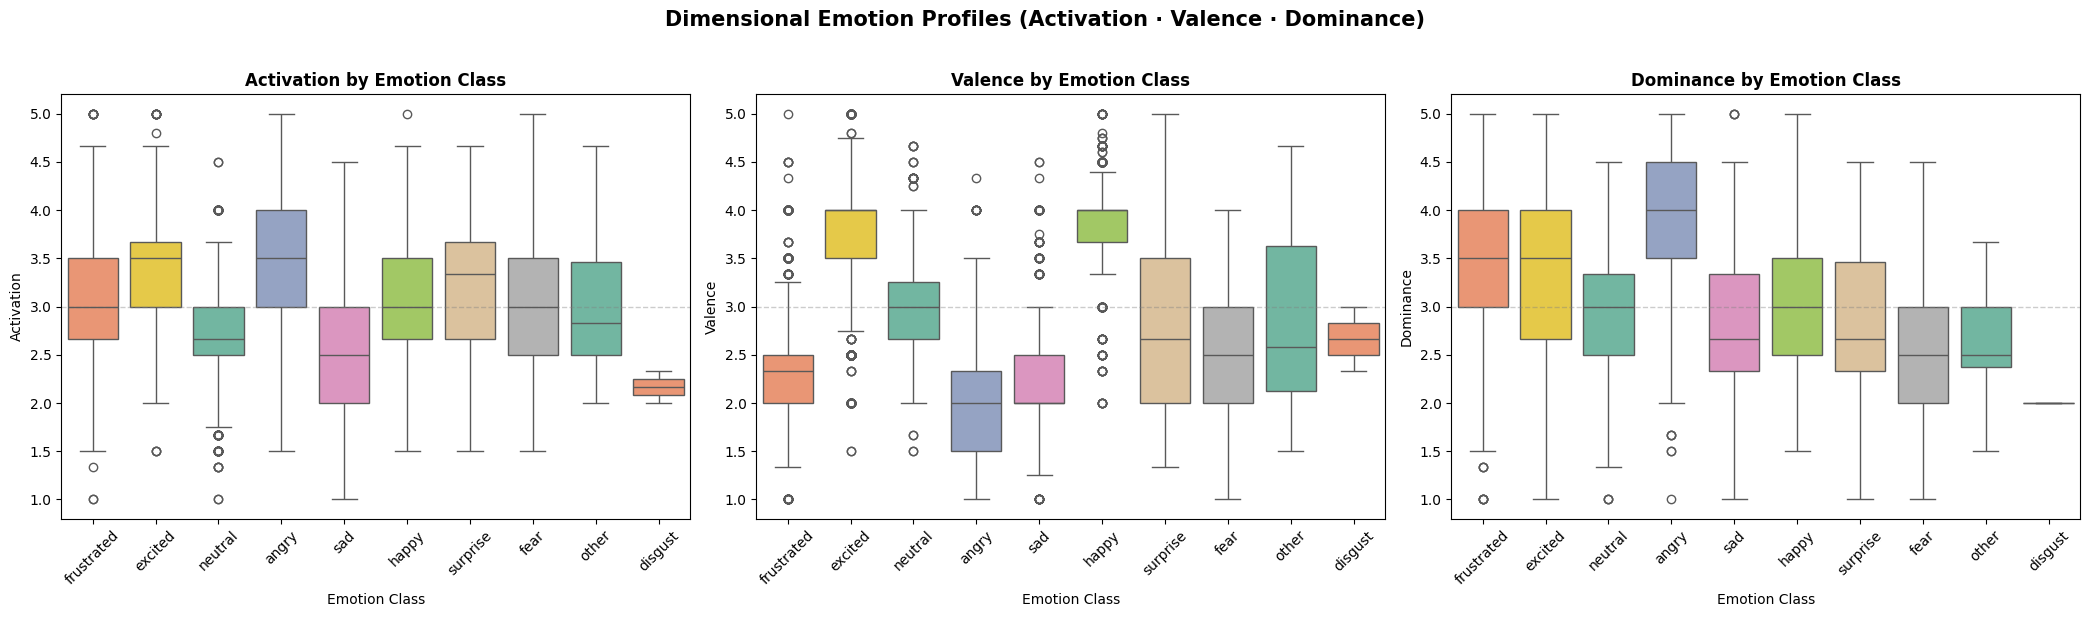

In [28]:
dims = ['EmoAct', 'EmoVal', 'EmoDom']
dim_titles = ['Activation', 'Valence', 'Dominance']
order = df_eda['major_emotion'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, (dim, title) in enumerate(zip(dims, dim_titles)):
    sns.boxplot(
        data=df_eda,
        x='major_emotion',
        y=dim,
        ax=axes[i],
        palette='Set2',
        order=order,
        hue='major_emotion',
        legend=False
    )
    axes[i].axhline(y=3.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    axes[i].set_title(f'{title} by Emotion Class', fontsize=12, weight='bold')
    axes[i].set_xlabel('Emotion Class')
    axes[i].set_ylabel(title)
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Dimensional Emotion Profiles (Activation · Valence · Dominance)', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

<u>**Conclusions:**</u>
`angry` scores highest on Activation (mean 3.60), followed by `excited` (3.34), both are high energy emotions. `sad` (2.60) and `neutral` (2.73) score lowest. On Valence, `happy` (3.91) and `excited` (3.77) are the most positive, while `angry` (1.94), `sad` (2.28), and `frustrated` (2.35) are the most negative. `angry` also scores highest on Dominance (3.89), consistent with anger being perceived as a controlling emotion, while `fear` (2.59) and `sad` (2.81) score low. These patterns align well with the Russell circumplex model, validating the dimensional annotation quality in IEMOCAP.

Emotion distribution by session type — improvised vs. scripted

Session type counts:
session_type
scripted      5255
improvised    4784
Name: count, dtype: int64



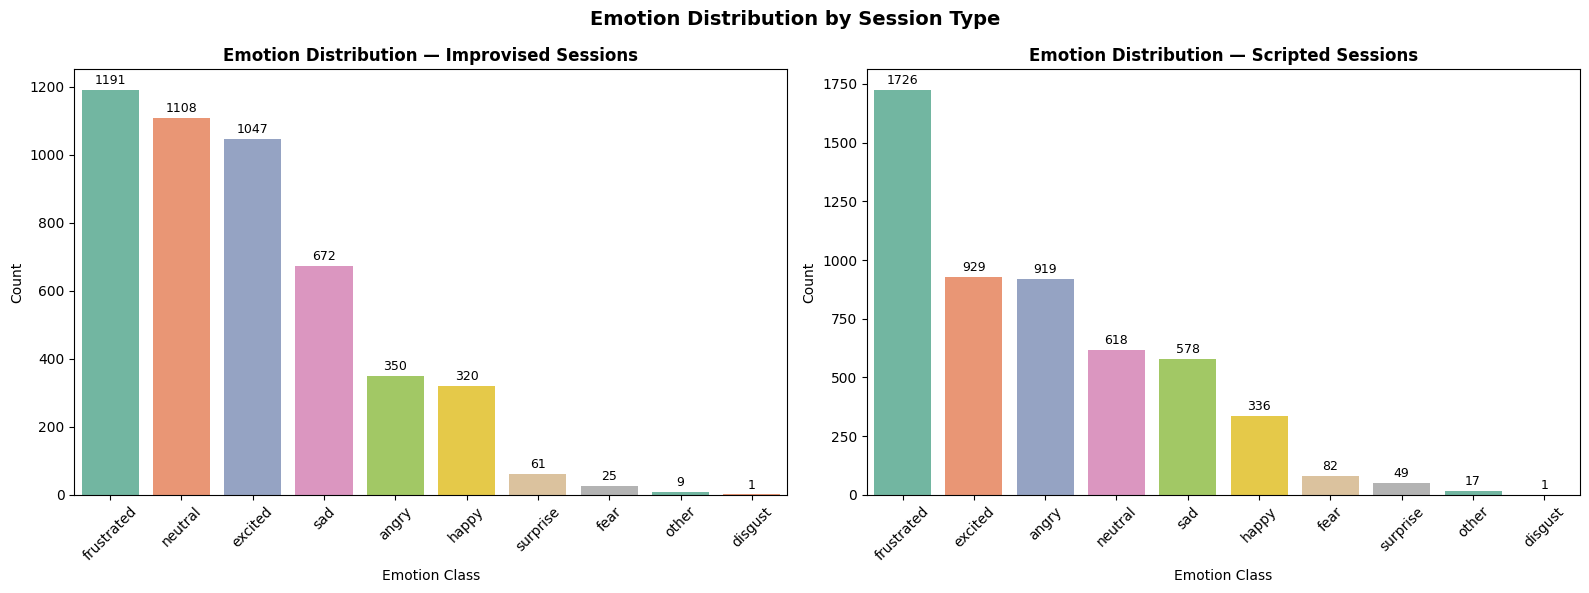

In [29]:
df_eda['session_type'] = df_eda['file'].apply(
    lambda x: 'improvised' if 'impro' in x else 'scripted'
)

print("Session type counts:")
print(df_eda['session_type'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, stype in zip(axes, ['improvised', 'scripted']):
    subset = df_eda[df_eda['session_type'] == stype]
    counts = subset['major_emotion'].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax,
                palette='Set2', hue=counts.index, legend=False)
    ax.set_title(f'Emotion Distribution — {stype.capitalize()} Sessions',
                 fontsize=12, weight='bold')
    ax.set_xlabel('Emotion Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=2, fontsize=9)

plt.suptitle('Emotion Distribution by Session Type', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

<u>**Conclusions:**</u>
The dataset splits between scripted (5,255 utterances, 52%) and improvised (4,784 utterances, 48%) sessions. The distributions differ noticeably: improvised sessions have proportionally more `neutral` speech (23% vs 12%), while scripted sessions have more `angry` utterances (18% vs 7%), likely reflecting the more dramatic nature of movie dialogue used in scripted scenarios. Session type may therefore act as a confound in modeling, and the acted nature of both session types remains a broader limitation when generalising to real-world spontaneous speech.

Acoustic feature comparison between female and male speakers

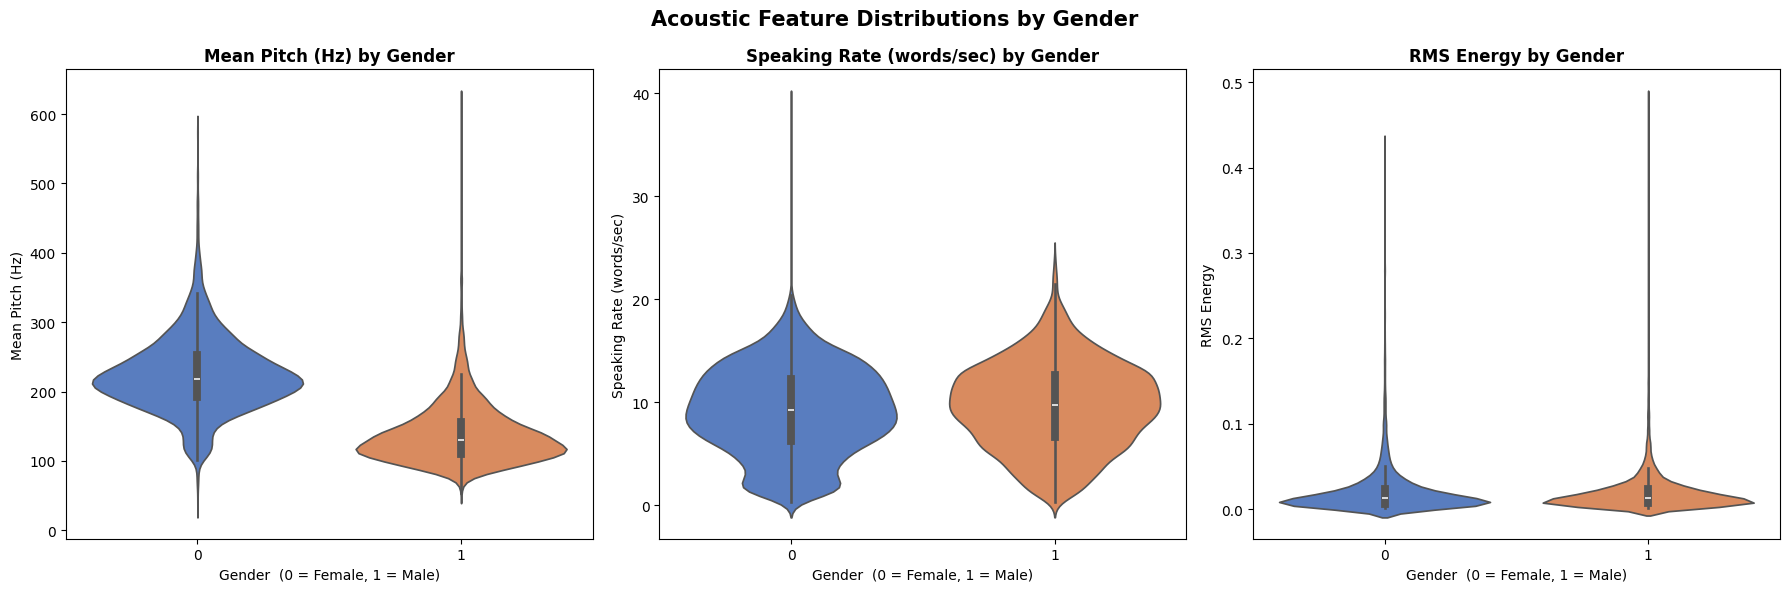

In [30]:
acoustic_features = ['pitch_mean', 'speaking_rate', 'rms']
feature_labels = ['Mean Pitch (Hz)', 'Speaking Rate (words/sec)', 'RMS Energy']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (feat, label) in enumerate(zip(acoustic_features, feature_labels)):
    sns.violinplot(
        data=df_eda,
        x='gender',
        y=feat,
        ax=axes[i],
        palette='muted',
        hue='gender',
        legend=False
    )
    axes[i].set_title(f'{label} by Gender', fontsize=12, weight='bold')
    axes[i].set_xlabel('Gender  (0 = Female, 1 = Male)')
    axes[i].set_ylabel(label)

fig.suptitle('Acoustic Feature Distributions by Gender', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

<u>**Conclusions:**</u>
Female speakers have a noticeably higher mean pitch than male speakers, consistent with known physiological differences in vocal anatomy. Speaking rate and RMS energy distributions are broadly similar across genders. These acoustic differences are worth considering during modeling, a classifier that does not account for speaker identity may inadvertently learn gender as a proxy for emotion, which could inflate performance on seen speakers but reduce generalisation to new ones.

# <h1 style='color:purple;'>**EDA Summary**</h1>

### Key Findings

**Dataset overview**
- 10,039 utterances. 10 speakers (5F / 5M). 5 sessions. 22 features
- No missing values; emotion soft-label scores sum to 1 per row (floating-point precision only)

**Class distribution**
- Heavily imbalanced: `frustrated` (29.1%) and `excited` (19.7%) dominate; `neutral` is third at 17.2%
- Extremely sparse: `disgust` (2 instances) and `other` (26 instances): too small to model reliably
- Rare but present: `surprise` (1.1%) and `fear` (1.1%)

**Emotion structure**
- Soft-label scores align strongly with `major_emotion` (heatmap diagonal is clear)
- Dimensional features (EmoAct / EmoVal / EmoDom) map naturally to the Russell circumplex model
- Valence Activation 2D space shows meaningful clustering by emotion group

**Acoustic signals**
- `EmoAct` and `EmoDom` are the most correlated dimensional pair (r = 0.59)
- `EmoAct` correlates moderately with `rms` (0.46), `pitch_std` (0.43), `pitch_mean` (0.35), and `speaking_rate` (0.31)
- `EmoVal` is largely uncorrelated with all acoustic features: valence is harder to predict from acoustics
- `rms` and `relative_db` are near-uncorrelated (r = -0.06) and capture different aspects of loudness
- Female speakers have higher mean pitch (~224 Hz) than male speakers (~139 Hz)

**Dataset limitations**
- Acted, not spontaneous speech: results may not generalise to real world conversation
- Only 10 speakers: speaker independent evaluation (GroupKFold by speaker) is essential to avoid inflated results
- Session type (improvised vs. scripted) introduces variation: more neutral in improvised, more angry in scripted

**Modeling recommendations**
- Use speaker independent cross validation (GroupKFold on speaker ID)
- Use Unweighted Accuracy (UAR) as primary metric due to class imbalance
- Exclude `disgust` and consider excluding `other`. Both are too sparse for reliable classification
- Keep both `rms` and `relative_db`. They are not redundant

# <h1 style="color:purple;">**Our Research Question**</h1>
# *?*